In [ ]:
import pandas as pd
import datetime
import schedule
import time


class ETLPipeline:
    def __init__(self, input_path, output_path):
        self.input_path = input_path
        self.output_path = output_path
        self.data = None

    def extract(self):
        print("Extracting data...")
        try:
            self.data = pd.read_csv(self.input_path)  
            print("Data extracted successfully!")
        except Exception as e:
            print(f"Error in extract: {e}")

    def transform(self):
        print("Transforming data...")
        try:
            if self.data is not None:
                self.data = self.data.dropna()

                if "price" in self.data.columns:
                    self.data["price"] = self.data["price"] * 1.1

                self.data["processed_at"] = datetime.datetime.now()  
                print("Data transformed successfully!")
        except Exception as e:
            print(f"Error in transform: {e}")

    def load(self):
        print("Loading data...")
        try:
            if self.data is not None:
                self.data.to_csv(self.output_path, index=False)
                print("Data loaded successfully!")
        except Exception as e:
            print(f"Error in load: {e}")

    def run_etl(self):
        self.extract()
        self.transform()
        self.load()


def job():
    print("\nRunning ETL at:", time.ctime())
    pipeline = ETLPipeline("data.csv", "cleaned_data.csv")
    pipeline.run_etl()


# 🔥Run every 5 seconds (for testing)
schedule.every(60).seconds.do(job)

print("Scheduler started... Running every 5 seconds")

while True:
    schedule.run_pending()
    time.sleep(1)   

Scheduler started... Running every 5 seconds

Running ETL at: Wed Apr 29 07:33:03 2026
Extracting data...
Data extracted successfully!
Transforming data...
Data transformed successfully!
Loading data...
Data loaded successfully!


In [ ]:
def my_generator(n):
    for i in range(1,n+1):
        yield i

for i in my_generator(11):
    print(i)
    



1
2
3
4
5
6
7
8
9
10
11


In [ ]:
def check_prime(n):
    for num in range(2,n+1):
        is_prime = True
        
        for i in range(2,int(num**0.5)+1):
            if num%i == 0:
                is_prime = False
                
        
        if is_prime:
            yield num
            

for p in check_prime(20):
    print(p)
        

2
3
5
7
11
13
17
19


In [ ]:
from collections import Counter,OrderedDict,namedtuple,defaultdict,deque

In [ ]:
fruits = ['banana','apple','mango','banana','banana','apple','mango']

count = Counter(fruits)
print(Counter("banana"))
print(count)



Counter({'a': 3, 'n': 2, 'b': 1})
Counter({'banana': 3, 'apple': 2, 'mango': 2})


In [123]:
# d = defaultdict(list)
# di = defaultdict(int)


# di['y'] += 2
# d["x"].append('banana')

# d['x'].append('mango')

# print(d['x'])
# print(di['y'])


In [ ]:
dq = deque([1,2,3,4,5,6])

dq.append(7)
dq.appendleft(8)
dq.pop()
dq.popleft()
print(dq)

deque([1, 2, 3, 4, 5, 6])


In [ ]:
def square(n):
    for i in range(1,n+1):
        yield i*i
        

for j in square(5):
    print(j)

1
4
9
16
25


In [ ]:
def check_prime(n):
    for i in range(2,n+1):
        is_prime = True
        for j in range(2,int(i**0.5)+1):
            if i%j == 0:
                is_prime = False
    
        if is_prime:
            yield i
            

for x in check_prime(20):
    print(x)
        

2
3
5
7
11
13
17
19


In [ ]:
def prime_generator():
    num = 2
    
    while True:
        for i in range(2,int(num**0.5)+1):
            if num%i == 0:
                break
            
        else:
            yield num
                
        num += 1
            

In [ ]:
gen = prime_generator()

for _ in range(1):
    print(next(gen))
    


2


In [ ]:
class Count:
    def __init__(self,limit):
        self.limit = limit 
        self.current = 0
        
    def __iter__(self):        
        return self
    
    def __next__(self):
        if self.current >= self.limit:
            raise StopIteration
        
        self.current += 1 
        return self.current
    
    

for n in Count(10):
    print(n)

1
2
3
4
5
6
7
8
9
10


In [ ]:
class Employee:
    def __init__(self,name,salary):
        self._name = name
        self.__salary = salary
        
    def get_salary(self):
        return self.__salary
    
    def set_salary(self,amount):
        if amount > 0:
            self.__salary = amount
            
        else:
            print("Salary must be positive")
            
class Manager(Employee):
    def __init__(self,name,salary,age,address):
        self.age = age
        self.address = address
        
        super().__init__(name,salary)
        
    def display(self):
        print(self.get_salary())
        print(self.age)
        print(self.address)
        
        
m = Manager("Ram",10000,21,"kathmandu")
m.display() 
            
            


10000
21
kathmandu


In [ ]:
from abc import ABC, abstractmethod

class Shape(ABC):
    @abstractmethod
    def area(self):       # must be implemented by child
        pass

class Circle(Shape):
    def __init__(self, r):
        self.r = r
    def area(self):
        return 3.14 * self.r ** 2

In [ ]:
c = Circle(1)
print(c.area())

3.14


In [57]:
# nums = [1,2,3,4,5,6,7,8,9]

# even = list(filter(lambda x:x%2 ==0,nums))
# print(even)

# a = list(map(lambda x:x*2,nums))
# print(a)

# add = lambda x,y: x+y
# print(add(2,3))

prices = [1000,9000,4000,300,400,700,1500,1800]

discount_price = list(map(lambda x: 0.9*x,prices))
print(discount_price)

orders = list(filter(lambda x: x>1000,discount_price))
print(orders)


[900.0, 8100.0, 3600.0, 270.0, 360.0, 630.0, 1350.0, 1620.0]
[8100.0, 3600.0, 1350.0, 1620.0]


In [ ]:
def demo(*args,**kwargs):
    print(args)
    print(kwargs)
    
demo(1,2,3,name = "harry",age=21)

(1, 2, 3)
{'name': 'harry', 'age': 21}


In [ ]:
import logging

logging.basicConfig(level=logging.DEBUG)

logging.debug("Debugging info")       # development details
logging.info("Process started")       # general info
logging.warning("Low memory")         # something unexpected
logging.error("File not found")       # serious problem
logging.critical("System crashed") 

DEBUG:root:Debugging info
INFO:root:Process started
ERROR:root:File not found
CRITICAL:root:System crashed


In [ ]:
logging.basicConfig(
    filename="app.log",
    level=logging.WARNING,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.warning("This goes to the file")

In [ ]:
import csv

with open("data.csv","r") as file:
    reader = csv.reader(file)
    for row in reader:
        print(row)
        
with open("data1.csv","r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        print(row)
        
        
with open("data1.csv","w",newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["name","age"])
    writer.writerow(["harry",20])
    writer.writerow(["potter",24])

['id', 'name', 'price', 'quantity']
['1', 'Apple', '100', '5']
['2', 'Banana', '50', '10']
['3', 'Orange', '', '8']
['4', 'Mango', '150', '3']
['5', 'Grapes', '200', '']
['6', 'Pineapple', '120', '6']
['7', 'Watermelon', '80', '2']
{'name': 'harry', 'age': '20'}
{'name': 'potter', 'age': '24'}


In [ ]:
# With pandas
import pandas as pd

data = pd.read_csv("data.csv")
print(data)

data.to_csv("data2.csv",index=False)

   id        name  price  quantity
0   1       Apple  100.0       5.0
1   2      Banana   50.0      10.0
2   3      Orange    NaN       8.0
3   4       Mango  150.0       3.0
4   5      Grapes  200.0       NaN
5   6   Pineapple  120.0       6.0
6   7  Watermelon   80.0       2.0


In [ ]:
import json

data = {
  "id": 1,
  "name": "Dinesh Basnet",
  "email": "dinesh@example.com",
  "phone": "+977-9800000000",
  "age": 20,
  "isActive": True,
  "address": {
    "street": "Madhyapur Thimi",
    "city": "Bhaktapur",
    "country": "Nepal"
  },
  "skills": ["Python", "JavaScript", "SQL"],
  "education": {
    "degree": "Bachelor",
    "field": "Computer Science"
  }
}

    
with open('data.json','w') as f:
    json.dump(data,f,indent=4)
    
    
with open('data.json', 'r') as file:
    data = json.load(file)
    print(data)

{'id': 1, 'name': 'Dinesh Basnet', 'email': 'dinesh@example.com', 'phone': '+977-9800000000', 'age': 20, 'isActive': True, 'address': {'street': 'Madhyapur Thimi', 'city': 'Bhaktapur', 'country': 'Nepal'}, 'skills': ['Python', 'JavaScript', 'SQL'], 'education': {'degree': 'Bachelor', 'field': 'Computer Science'}}


In [ ]:
import requests

response = requests.get("https://jsonplaceholder.typicode.com/posts/1")

if response.status_code == 200:
    data = response.json()
    
else:
    print("data not found")
    




In [ ]:
from bs4 import BeautifulSoup

res = requests.get("https://www.hostinger.com/tutorials/how-to-run-a-python-script-in-linux")
soup = BeautifulSoup(res.text,"html.parser")

#By tags 
titles = soup.find_all('h2')

for title in titles:
    print(title.text)
    
    




You are unable to access hostinger.com
Why have I been blocked?
What can I do to resolve this?


In [ ]:


for chunk in pd.read_csv("evaluation.csv",chunksize=10000000):
    print(chunk.head())
    
    chunk.to_csv(
        "processed.csv",
        index = False
    )

                                             article  \
0  (CNN)Share, and your gift will be multiplied. ...   
1  (CNN)French striker Bafetimbi Gomis, who has a...   
2  (CNN)It was an act of frustration perhaps more...   
3  (CNN)A Pennsylvania community is pulling toget...   
4  (CNN)My vote for Father of the Year goes to Cu...   

                                          highlights  \
0  Zully Broussard decided to give a kidney to a ...   
1  Bafetimbi Gomis collapses within 10 minutes of...   
2  Rory McIlroy throws club into water at WGC Cad...   
3  Cayman Naib, 13, hasn't been heard from since ...   
4  Ruben Navarrette: Schilling deserves praise fo...   

                                         id  \
0  a4942dd663020ca54575471657a0af38d82897d6   
1  60736693e3b1b32d14337a317190c6606e879a85   
2  8cdf9cc3ed0276b7a7944cc18ba459355b5984ad   
3  2e6613d531843515bf5401286cc3e45c4df530d2   
4  fbc5ac3a3a7bb6c4d628cfbeef92b67bb18562f9   

                                     summar

In [ ]:
df1 = pd.DataFrame({
    'id':[1,2,3,4],
    'name':['A','B','C','D']
})

df2 = pd.DataFrame({
    'id':[1,3,4,5],
    'marks':[80,50,20,55]
})

merge = pd.merge(df1,df2,how="inner", on="id")

print(merge)

   id name  marks
0   1    A     80
1   3    C     50
2   4    D     20


In [ ]:
df1 = df1.set_index("id")
df2 = df2.set_index("id")

In [ ]:
df1.join(df2,how="left")

,name,marks
id,,
1,A,80.0
2,B,NaN
3,C,50.0
4,D,20.0


In [ ]:
df = pd.DataFrame({
    "name":["harry","ram"],
    "math":[50,80],
    "science":[58,84]
    
})
print(df)
melted = pd.melt(df,id_vars="name",var_name="subject",value_name="marks")
print(melted)

pivoted = melted.pivot(index="name",columns="subject",values="marks")
print(pivoted)

    name  math  science
0  harry    50       58
1    ram    80       84
    name  subject  marks
0  harry     math     50
1    ram     math     80
2  harry  science     58
3    ram  science     84
subject  math  science
name                  
harry      50       58
ram        80       84


In [ ]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "name":["Harry","Bob","Jhon","Alice","Games"],
    "age":[21,np.nan,22,np.nan,24],
    "score":[75,56,np.nan,np.nan,90],
    "Grade":['A','C',np.nan,'B','A']
})


In [ ]:
# Detecting missing values
df.isnull().sum()

df.isnull().sum()/len(df) * 100

name      0.0
age      40.0
score    40.0
Grade    20.0
dtype: float64

In [ ]:
#Dropping missing values

df.dropna()

df.dropna(subset="age")



,name,age,score,Grade
0,Harry,21.0,75.0,A
2,Jhon,22.0,NaN,NaN
4,Games,24.0,90.0,A


In [ ]:
# Filling missing values
df["age"].fillna(df["age"].mean(),inplace=True)

df["score"].fillna(df["score"].median(),inplace=True)



C:\Users\dinesh\AppData\Local\Temp\ipykernel_63220\1246085407.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean(),inplace=True)
C:\Users\dinesh\AppData\Local\Temp\ipykernel_63220\1246085407.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [ ]:
df["Grade"].fillna(df["Grade"].mode()[0],inplace=True)

In [ ]:
df = pd.DataFrame({
    "date":  ["2024-01-01", "2024-01-02", "2024-01-03",
              "2024-01-04", "2024-01-05", "2024-01-06", "2024-01-07"],
    "sales": [200, 220, np.nan, 250, 230, 270, 260]
})

In [ ]:
df["date"] = pd.to_datetime(df["date"])

# df.info()
# df.set_index("date",inplace=True)

df["date"].dt.year
df["date"].dt.month
df["date"].dt.dayofweek




0    0
1    1
2    2
3    3
4    4
5    5
6    6
Name: date, dtype: int32

In [ ]:
df.index.month
df.index.year
df.index.day
df.index.day_of_week

Index([0, 1, 2, 3, 4, 5, 6], dtype='int32', name='date')

In [ ]:
df = pd.DataFrame({
    "id":range(100000),
    "age":np.random.randint(18,60,100000),
    "salary":np.random.randint(20000,100000,100000),
    "department":np.random.choice(["HR","Manager","Sales"],100000)

    
})

df.info()

df.memory_usage(deep=True).sum() /1024**2




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          100000 non-null  int64 
 1   age         100000 non-null  int32 
 2   salary      100000 non-null  int32 
 3   department  100000 non-null  object
dtypes: int32(2), int64(1), object(1)
memory usage: 2.3+ MB


np.float64(6.64422607421875)

In [ ]:
df[["salary","age"]] = df[["salary","age"]].astype('int32')

df["department"] = df["department"].astype("category")

df.info()
df.memory_usage(deep=True).sum() /1024**2

df["department"].nbytes / 1024**2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          100000 non-null  int64   
 1   age         100000 non-null  int32   
 2   salary      100000 non-null  int32   
 3   department  100000 non-null  category
dtypes: category(1), int32(2), int64(1)
memory usage: 1.6 MB


0.09539031982421875

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,MinMaxScaler,StandardScaler
df = pd.DataFrame({
    "name":       ["Harry", "John", np.nan,  "Bob",  "Eve"],
    "age":        [21,      np.nan,   23,    22,     24],
    "salary":     [30000,   50000,  40000,  np.nan,  40000],
    "department": ["HR",    "engineering", "HR", "ENGINEERING", "Sales"],
    "level":      ["junior","senior","medium","junior","senior"]
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        4 non-null      object 
 1   age         4 non-null      float64
 2   salary      4 non-null      float64
 3   department  5 non-null      object 
 4   level       5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 332.0+ bytes


In [35]:
def drop_missing(df):
    df = df.dropna(subset=["name","age"])
    print(df)
    return df

def fill_missing(df):
    df["salary"] = df["salary"].fillna(df["salary"].median())
    print(df)
    return df

def standarized_text(df):
    df["department"] = df["department"].str.strip().str.lower()
    print(df)
    return df

def encode_level(df):
    oe = OrdinalEncoder(categories=[["junior","medium","senior"]])
    df["level"] = oe.fit_transform(df[["level"]])
    return df

def one_hot_department(df):
    return pd.get_dummies(df,columns=["department"])

def convert_dtype(df):
    df["age"] = df["age"].astype('int32')
    df["salary"] = df["salary"].astype('int32')
    print(df)
    return df

    
def scale_columns(df):
    print(df[["age", "salary"]].dtypes)   # should be float64/int64
    print(df[["age", "salary"]].head())
    scalar = StandardScaler()
    df[["age","salary"]] = scalar.fit_transform([["age","salary"]])
    return df

def run_pipeline(df):
    df = df.copy()
    df = drop_missing(df)
    df = fill_missing(df)
    df = standarized_text(df)
    df = encode_level(df)
    df = one_hot_department(df)
    df = convert_dtype(df)
    df = scale_columns(df)
    return df

cleaned = run_pipeline(df)
print(df)

    name   age   salary   department   level
0  Harry  21.0  30000.0           HR  junior
3    Bob  22.0      NaN  ENGINEERING  junior
4    Eve  24.0  40000.0        Sales  senior
    name   age   salary   department   level
0  Harry  21.0  30000.0           HR  junior
3    Bob  22.0  35000.0  ENGINEERING  junior
4    Eve  24.0  40000.0        Sales  senior
    name   age   salary   department   level
0  Harry  21.0  30000.0           hr  junior
3    Bob  22.0  35000.0  engineering  junior
4    Eve  24.0  40000.0        sales  senior
    name  age  salary  level  department_engineering  department_hr  \
0  Harry   21   30000    0.0                   False           True   
3    Bob   22   35000    0.0                    True          False   
4    Eve   24   40000    2.0                   False          False   

   department_sales  
0             False  
3             False  
4              True  
age       int32
salary    int32
dtype: object
   age  salary
0   21   30000
3   22   35

ValueError: could not convert string to float: 'age'

In [45]:
import numpy as np
from scipy import stats

sample_mean = 492
population_mean = 500   # H0: mean = 500
sigma = 20              # known population std
n = 50

z = (sample_mean - population_mean) / (sigma/np.sqrt(n))
print(f"Z-statistics: {z}")

p_value = stats.norm.sf(abs(z)) *2
print(f"p-value :{p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Z-statistics: -2.8284271247461903
p-value :0.0094
Reject H0


In [50]:
sample_mean = 71.4
std = 9.2
alpha = 0.05
mean = 75

t = (mean-sample_mean)/(std/np.sqrt(30))
print(t)

p_value  = stats.t.sf(abs(t),29) *2
print(p_value)

if p_value < alpha:
    print("Reject H0")
    
else:
    print("failed to reject h0")


2.1432621815419513
0.04061146679107446
Reject H0


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.DataFrame({
    'OrderID':      ['O01', 'O02', 'O03', 'O04', 'O05', 'O06'],
    'Category':     ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Books', 'Books'],
    'Price':        [15000, None, 22000, 1800, 450, None],
    'Quantity':     [2, 5, 1, None, 8, 3],
    'Rating':       [4.5, 3.8, None, 4.1, 4.7, 3.9],
    'DeliveryDays': [3, 5, 2, None, 4, 6]
})

# Handle missing values
df['Price']        = df['Price'].fillna(df['Price'].mean())
df['Quantity']     = df['Quantity'].fillna(df['Quantity'].median())
df['Rating']       = df['Rating'].fillna(df['Rating'].mean())
df['DeliveryDays'] = df['DeliveryDays'].fillna(df['DeliveryDays'].median())

In [ ]:

numeric_df = df[['Price','Quantity','Rating','DeliveryDays']]
corr_matrix = numeric_df.corr()

,Price,Quantity,Rating,DeliveryDays
Price,1.000000,-0.754178,-0.165821,-0.516734
Quantity,-0.754178,1.000000,0.322886,0.395453
Rating,-0.165821,0.322886,1.000000,-0.530723
DeliveryDays,-0.516734,0.395453,-0.530723,1.000000


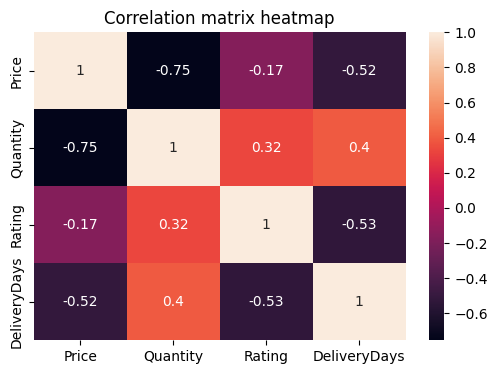

In [67]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True
)
plt.title("Correlation matrix heatmap")
plt.show()

In [ ]:
# from collections import defaultdict,Counter

# records = [
#     {'name': 'Alice', 'ward': 'Cardiology'},
#     {'name': 'Bob',   'ward': 'Neurology'},
#     {'name': 'Carol', 'ward': 'Cardiology'},
# ]

# ward_patient = defaultdict(list)


# for record in records:
#     ward_patient[record['ward']].append(record['name'])
# ward_patient["y"].append("Hari")
# print(ward_patient)
    

In [ ]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017")
db = client['hospital']
collection = db['patients']

with open("data.json",'r') as file:
    data = json.load(file)
    
collection.insert_many(data)

for record in collection.find():
    print(record)

NameError: name 'json' is not defined

In [5]:
from bs4 import BeautifulSoup
import pandas as pd

# Sample HTML page
html = """
<html>
<body>
    <table>
        <tr>
            <th>Ward</th>
            <th>Patients</th>
            <th>Doctors</th>
            <th>Beds</th>
        </tr>
        <tr><td>ICU</td><td>10</td><td>5</td><td>15</td></tr>
        <tr><td>Cardiology</td><td>20</td><td>8</td><td>25</td></tr>
        <tr><td>Neurology</td><td>15</td><td>6</td><td>20</td></tr>
        <tr><td>Orthopedics</td><td>12</td><td>4</td><td>18</td></tr>
    </table>
</body>
</html>
"""

# Step 1 — parse HTML

soup = BeautifulSoup(html,'html.parser')


headers = [th.text for th in soup.find_all('th')]

print(headers)

ward_stat = []

for tr in soup.find_all("tr")[1:]:
    row_data = [td.text for td in tr.find_all('td')]
    ward_stat.append(dict(zip(headers,row_data)))
    

    
print(ward_stat)
df = pd.DataFrame(ward_stat)
df.head()

['Ward', 'Patients', 'Doctors', 'Beds']
[{'Ward': 'ICU', 'Patients': '10', 'Doctors': '5', 'Beds': '15'}, {'Ward': 'Cardiology', 'Patients': '20', 'Doctors': '8', 'Beds': '25'}, {'Ward': 'Neurology', 'Patients': '15', 'Doctors': '6', 'Beds': '20'}, {'Ward': 'Orthopedics', 'Patients': '12', 'Doctors': '4', 'Beds': '18'}]


,Ward,Patients,Doctors,Beds
0,ICU,10,5,15
1,Cardiology,20,8,25
2,Neurology,15,6,20
3,Orthopedics,12,4,18


In [40]:
import pandas as pd
import statsmodels.formula.api as smf

# Example dataset (replace with Q4(b) dataset if given)
df = pd.DataFrame({
    'Temperature': [30, 32, 35, 28, 26, 31],
    'Humidity': [70, 65, 60, 80, 85, 75],
    'Windspeed': [10, 12, 15, 8, 7, 11]
})

# Fit linear regression model
model = smf.ols('Temperature ~ Humidity + Windspeed', data=df).fit()

# Print summary
print(model.summary())
print(model.rsquared)

                            OLS Regression Results                            
Dep. Variable:            Temperature   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     155.4
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           0.000934
Time:                        19:29:57   Log-Likelihood:               -0.88279
No. Observations:                   6   AIC:                             7.766
Df Residuals:                       3   BIC:                             7.141
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.9452      6.174      3.716      0.0

a:\Advanced_python_lab\venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [47]:
sales = [
    {'Product': 'Laptop',  'UnitsSold': 5,  'Revenue': 75000},
    {'Product': 'Phone',   'UnitsSold': 20, 'Revenue': 30000},
    {'Product': 'Tablet',  'UnitsSold': 8,  'Revenue': 20000},
    {'Product': 'Monitor', 'UnitsSold': 3,  'Revenue': 9000},
    {'Product': 'Camera',  'UnitsSold': 4,  'Revenue': 40000},
]

sales_with_unitprice = list(map(lambda x:{**x,'UnitPrice':x['Revenue'] / x['UnitsSold']},sales))
print(sales_with_unitprice)

filtered_record = list(filter(lambda x : x['UnitPrice'] > 2000,sales_with_unitprice))

print(filtered_record)

[{'Product': 'Laptop', 'UnitsSold': 5, 'Revenue': 75000, 'UnitPrice': 15000.0}, {'Product': 'Phone', 'UnitsSold': 20, 'Revenue': 30000, 'UnitPrice': 1500.0}, {'Product': 'Tablet', 'UnitsSold': 8, 'Revenue': 20000, 'UnitPrice': 2500.0}, {'Product': 'Monitor', 'UnitsSold': 3, 'Revenue': 9000, 'UnitPrice': 3000.0}, {'Product': 'Camera', 'UnitsSold': 4, 'Revenue': 40000, 'UnitPrice': 10000.0}]
[{'Product': 'Laptop', 'UnitsSold': 5, 'Revenue': 75000, 'UnitPrice': 15000.0}, {'Product': 'Tablet', 'UnitsSold': 8, 'Revenue': 20000, 'UnitPrice': 2500.0}, {'Product': 'Monitor', 'UnitsSold': 3, 'Revenue': 9000, 'UnitPrice': 3000.0}, {'Product': 'Camera', 'UnitsSold': 4, 'Revenue': 40000, 'UnitPrice': 10000.0}]


In [50]:
import requests

url = "https://jsonplaceholder.typicode.com/posts/"
page = 1
all_data = []

while True:
    
    response = requests.get(url,params={'page':page})
    
    if response.status_code != 200:
        print("Something went wrong")
        break
        
    data = response.json()
    
    if not data:
        print("no data found with this page")
        break
    
    if page > 100:
        break
    print(f"Data is :{data}")
    all_data.extend(data)
    page += 1
    
    
df = pd.DataFrame(all_data)
print(f"\n Total records:{len(df)}")
print(df)
    

    
        

Data is :[{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}, {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}, {'userId': 1, 'id': 3, 'title': 'ea molestias quasi exercitationem repellat qui ipsa sit aut', 'body': 'et iusto sed quo iure\nvoluptatem occaecati omnis eligendi aut ad\nvoluptatem doloribus vel accusantium quis pariatur\nmolestiae porro eius odio et labore et velit aut'}, {'userId': 1, 'id': 4, 'title': 'eum et est occaecati', 'body': 'ullam et saepe reiciendis voluptatem adipisci\nsit amet autem assumenda provident rerum culpa\nq

In [ ]:
import pandas as pd
import logging
import numpy as np

# Sample data (replace with your dataset)
df = pd.DataFrame({
    'Region': ['North', 'North', 'South', 'South', 'North'],
    'Product': ['A', 'B', 'A', 'B', 'A'],
    'Revenue': [1000, 2000, np.nan, 2500, np.nan]
})

logging.basicConfig(
    filename = "report.log",
    level=logging.DEBUG,
    format = '%(asctime)s - %(levelname)s - %(message)s'
)

# # Create pivot table
# pivot = pd.pivot_table(
#     df,
#     values='Revenue',
#     index='Region',
#     columns='Product',
#     aggfunc=['mean','sum']
# )

# print(pivot)
missing_perct = df.isnull().mean() * 100

print(missing_perct)           



for col, pct in missing_perct.items():
    if pct > 10:
        logging.warning(f" Column:{col} has {pct}% missing values")
        print("more than 10% values")
        
    
df_clean = df.dropna(subset=['Revenue'],inplace=True)
logging.info("Missing values dropeed successfully")
    







Region      0.0
Product     0.0
Revenue    40.0
dtype: float64
more than 10% values


In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

def data_cleaning_pipeline():
    # Columns
    numeric_cols = ["Price","Quantity","Rating"]
    categorical_cols = ["Category"]
    

    # Numerical pipeline: imput missing values + scale
    numeric_pipeline = Pipeline([
        ("impute",SimpleImputer(strategy = "median")),
        ("scalar",StandardScaler())
    ])
    
    categorical_pipeline = Pipeline([
        ("encoding",OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprosessor = ColumnTransformer([
        ("num",numeric_pipeline,numeric_cols),
        ("cat",categorical_pipeline,categorical_cols)
    ])
    
    return preprosessor


df = pd.read_csv("data1.csv")

pipeline = data_cleaning_pipeline()

cleaned_data = pipeline.fit_transform(df)
cleaned_df = pd.DataFrame(cleaned_data)
print(cleaned_df)



          0         1         2    3    4    5    6
0  0.407966 -0.088045  1.010386  0.0  1.0  0.0  0.0
1 -1.095066 -0.088045 -0.901155  1.0  0.0  0.0  0.0
2  1.052122 -0.968496  0.191154  0.0  1.0  0.0  0.0
3 -0.021472  0.792406 -0.355000  0.0  0.0  0.0  1.0
4 -0.450910 -0.088045 -0.081923  1.0  0.0  0.0  0.0
5  2.125717 -0.968496  2.102695  0.0  1.0  0.0  0.0
6 -1.524504  2.553308 -1.720387  0.0  0.0  0.0  1.0
7 -0.021472 -0.088045 -0.081923  0.0  0.0  1.0  0.0
8 -0.665629 -0.968496 -0.628078  0.0  0.0  1.0  0.0
9  0.193247 -0.088045  0.464231  1.0  0.0  0.0  0.0


In [1]:
from ydata_profiling import ProfileReport
import pandas as pd
df = pd.read_csv('data1.csv')

profile = ProfileReport(df,explorative=True)
profile.to_file('report.html')


ModuleNotFoundError: No module named 'pkg_resources'

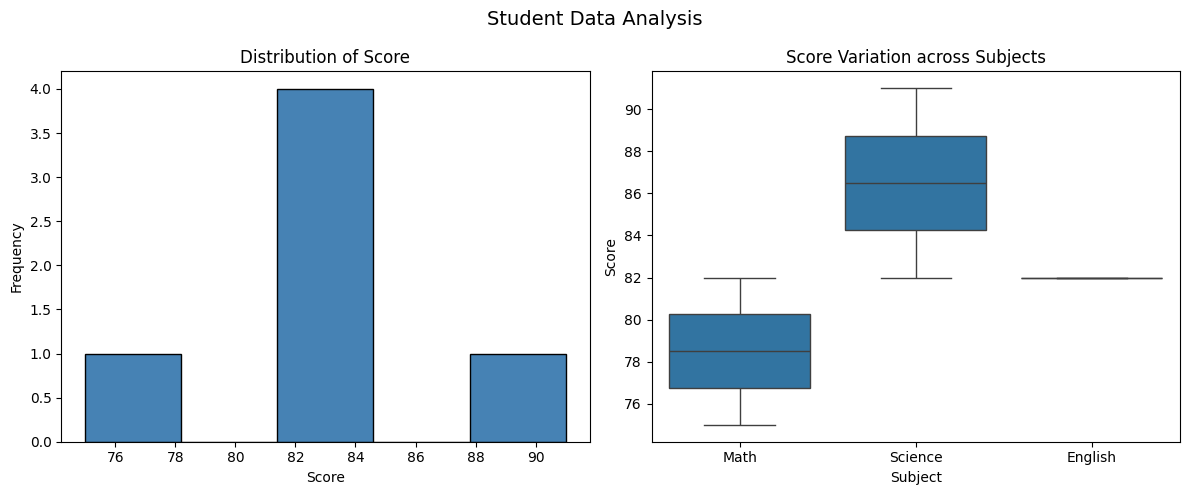

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
df = pd.DataFrame({
    'StudentID':     ['S01', 'S02', 'S03', 'S04', 'S05', 'S06'],
    'Subject':       ['Math', 'Science', 'Math', 'English', 'Science', 'English'],
    'Score':         [82, None, 75, None, 91, None],
    'Grade':         ['B', 'A', 'C', 'B', 'A', 'C'],
    'AttendancePct': [90, 85, None, 78, 92, 70],
    'StudyHours':    [5, 6, 4, None, 7, 3]
})

# Handle missing values
df['Score']         = df['Score'].fillna(df['Score'].median())
df['AttendancePct'] = df['AttendancePct'].fillna(df['AttendancePct'].median())
df['StudyHours']    = df['StudyHours'].fillna(df['StudyHours'].median())

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Histogram of Score
axes[0].hist(df['Score'],bins =5,color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

# Right — Boxplot of Score by Subject
sns.boxplot(data=df,x="Subject",y="Score",ax=axes[1])
axes[1].set_title('Score Variation across Subjects')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Score')

# Figure title
fig.suptitle('Student Data Analysis', fontsize=14)

plt.tight_layout()
plt.show()



In [41]:
import plotly.express as px

fig = px.scatter(df,x="Score",y="AttendancePct",color="Subject",size="StudyHours")
fig.show()

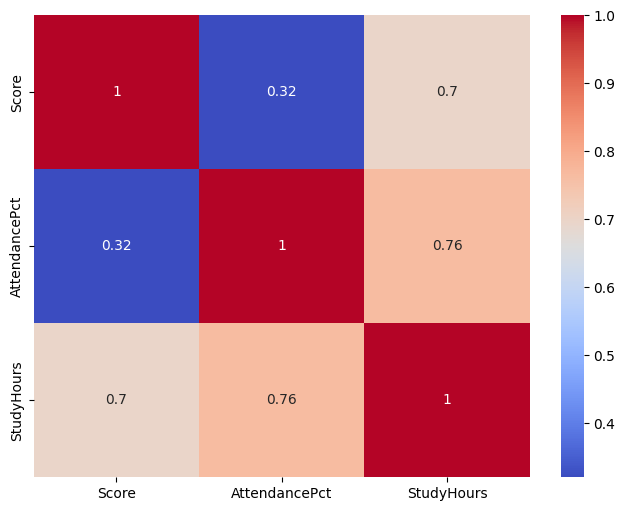

In [52]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="Viridis"
)

fig = px.scatter_matrix(df,dimensions=["Score","AttendancePct","StudyHours"])
fig.show()


In [27]:
import plotly.express as px
df = pd.DataFrame({
    "Product":["Laptop","Phone","Laptop","Tablet","Phone"],
    "Revenue":[120000,80000,90000,75000,60000],
    "Region":["North","South","North","East","South"],
    "UnitSold":[50,45,30,25,20]
})

grouped = df.groupby(["Product","Region"],as_index=False)[["Revenue","UnitSold"]].sum()
print(grouped)

px.bar(grouped,x="Product",y="Revenue",hover_data="UnitSold",color="Region")



  Product Region  Revenue  UnitSold
0  Laptop  North   210000        80
1   Phone  South   140000        65
2  Tablet   East    75000        25


In [29]:
# grouped = df.groupby(["Product", "Region"], as_index=False).agg({
#     "Revenue": "sum",
#     "UnitSold": "sum"
# })
grouped = df.groupby(['Product','Region'],as_index=False)[['Revenue','UnitSold']].sum()

# 🔹 Create grouped bar chart
fig = px.bar(
    grouped,
    x="Product",
    y="Revenue",
    color="Region",           # grouped bars
    barmode="group",          # side-by-side bars
    hover_data=["UnitSold"], # hover info
    title="Total Revenue per Product by Region"
)

fig.show()

In [4]:
import pandas as pd
class ETLPipeline:
    def __init__(self,filepath):
        self.filepath = filepath
        self.df = None
    
    def extract(self):
        self.df = pd.read_csv(self.filepath)
        
    def rename_column(self):
        self.df = self.df.rename(columns = {"student_name":"Name","student_score":"Score"})
        
    def filter(self):
        self.df = self.df[self.df["Price"]>800]
        
    def save(self,output_path):
        self.df.to_csv(output_path,index=False)
        
        
pipeline = ETLPipeline("data1.csv")

pipeline.extract()
pipeline.filter()
pipeline.save('data4.csv')

        
    

In [20]:
import pandas as pd
import openpyxl
from openpyxl import Workbook

df = pd.DataFrame({
    'StudentID':     ['S01', 'S02', 'S03', 'S04', 'S05', 'S06'],
    'Subject':       ['Math', 'Science', 'Math', 'English', 'Science', 'English'],
    'Score':         [82, None, 75, None, 91, None],
    'Grade':         ['B', 'A', 'C', 'B', 'A', 'C'],
    'AttendancePct': [90, 85, None, 78, 92, 70],
    'StudyHours':    [5, 6, 4, None, 7, 3]
})

df['Score']         = df['Score'].fillna(df['Score'].median())
df['AttendancePct'] = df['AttendancePct'].fillna(df['AttendancePct'].median())
df['StudyHours']    = df['StudyHours'].fillna(df['StudyHours'].median())

grouped = df.groupby('Subject')[['Score','AttendancePct','StudyHours']].mean()
print(grouped)

grouped.to_excel('grouped.xlsx',sheet_name='grouped',engine='openpyxl')

summary = df[['Score','AttendancePct','StudyHours']].agg(
    ['mean','median','std','min','max']
).round(2)

summary.to_excel('student_report.xlsx',sheet_name='Summary',engine='openpyxl')
print('Report saved')



         Score  AttendancePct  StudyHours
Subject                                  
English   82.0           74.0         4.0
Math      78.5           87.5         4.5
Science   86.5           88.5         6.5
Report saved


In [41]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "StationID": ["W01", "W02", "W03", "W04", "W05", "W06"],
    "Region": ["North", "South", "North", "East", "South", "East"],
    "Temperature": [32, np.nan, 35, 28, np.nan, 30],
    "Humidity": [65, 78, np.nan, 70, 82, np.nan],
    "Windspeed": [12, 8, 15, np.nan, 10, 11],
    "Rainfall": [np.nan, 55, 40, 30, 60, 45]
})

df['Temperature'] = df['Temperature'].fillna(df["Temperature"].median())
df['Humidity'] = df['Humidity'].fillna(df["Humidity"].median())
df['Windspeed'] = df['Windspeed'].fillna(df["Windspeed"].median())
df['Rainfall'] = df['Rainfall'].fillna(df["Rainfall"].median())

summary = df[["Humidity",'Rainfall','Temperature','Windspeed']].agg(
    ['mean','median','std','min','max']
    
)
summary.to_excel('weather_report.xlsx',sheet_name='Summary',engine='openpyxl')

grouped_report = df.groupby('Region')[['Temperature','Humidity','Windspeed','Rainfall']].mean()

grouped_report.to_excel('grouped_weather_report.xlsx',sheet_name="summary",engine='openpyxl')


In [50]:
import pandas as pd

# Dataset
df = pd.DataFrame({
    'OrderID':      ['O01', 'O02', 'O03', 'O04', 'O05', 'O06'],
    'Category':     ['Electronics', 'Clothing', 'Electronics',
                     'Clothing', 'Books', 'Books'],
    'Price':        [15000, None, 22000, 1800, 450, None],
    'Quantity':     [2, 5, 1, None, 8, 3],
    'Rating':       [4.5, 3.8, None, 4.1, 4.7, 3.9],
    'DeliveryDays': [3, 5, 2, None, 4, 6]
})

# Handle missing values
df['Price']        = df['Price'].fillna(df['Price'].median())
df['Quantity']     = df['Quantity'].fillna(df['Quantity'].median())
df['Rating']       = df['Rating'].fillna(df['Rating'].median())
df['DeliveryDays'] = df['DeliveryDays'].fillna(df['DeliveryDays'].median())

summary = df[['Price','Rating','DeliveryDays']].agg(
    ['mean','median','std','min','max']
).round(2)

category_count = df.groupby('Category')['OrderID'].count().reset_index()
category_count.columns = ['Category','OrderID']

html = f"""

<html>
<head>
<title>Automated html report</title>
</head>
<body>
<h1>Sales Data Report</h1>
<h2>Summary statistics</h2>
{summary.to_html()}

<h2>Orders per Category</h2>
{category_count.to_html(index=False)}
</body>
</html>
"""

with open("report.html",'w') as file:
    file.write(html)
    
print("Html report generated successfully")

Html report generated successfully
